# The Summit — Trust & Scale
### Data GOLD Field Notes · Series Demo 05

Six terms, five sections: **Data Quality**, **Data Lineage**, **Data Catalog**, **Fault Tolerance**, and **Elasticity vs. Scalability** as a closing comparison.

Each section is self-contained. Run top to bottom, or jump to the term you're studying.


## Setup

In [1]:
import time
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


## Section A — Data Quality

Whether the data is accurate, consistent, and reliable enough to act on. Below: three quality rules run against four customer records, with a pass/fail scorecard.


In [3]:
def check_completeness(records, required_fields):
    missing = sum(1 for r in records for f in required_fields if not r.get(f))
    return missing == 0, missing

def check_uniqueness(records, key):
    keys = [r[key] for r in records]
    dupes = len(keys) - len(set(keys))
    return dupes == 0, dupes

def check_validity(records, field, valid_fn):
    invalid = sum(1 for r in records if not valid_fn(r.get(field)))
    return invalid == 0, invalid

customers_q = [
    {"id": 1, "email": "alicia@example.com", "mrr": 129.00},
    {"id": 2, "email": "bob@example.com",     "mrr": -10.00},  # invalid: negative mrr
    {"id": 3, "email": "",                    "mrr": 59.00},   # incomplete: missing email
    {"id": 1, "email": "dupe@example.com",    "mrr": 40.00},   # duplicate id
]

rules = {
    "completeness (email required)": lambda: check_completeness(customers_q, ["email"]),
    "uniqueness (id)":                lambda: check_uniqueness(customers_q, "id"),
    "validity (mrr >= 0)":            lambda: check_validity(customers_q, "mrr", lambda v: v is not None and v >= 0),
}

print("Running quality rules against 4 customer records:\n")
passed = 0
for name, rule in rules.items():
    ok, count = rule()
    status = "PASS" if ok else f"FAIL ({count} issue(s))"
    passed += ok
    print(f"  {name:<32} {status}")

print(f"\n{passed}/{len(rules)} quality rules passed. This dataset should not be trusted as-is.")


Running quality rules against 4 customer records:

  completeness (email required)    FAIL (1 issue(s))
  uniqueness (id)                  FAIL (1 issue(s))
  validity (mrr >= 0)              FAIL (1 issue(s))

0/3 quality rules passed. This dataset should not be trusted as-is.


## Section B — Data Lineage

The traceable path data takes from source to destination. Below: a value moving through three pipeline steps, with every change to it logged along the way.


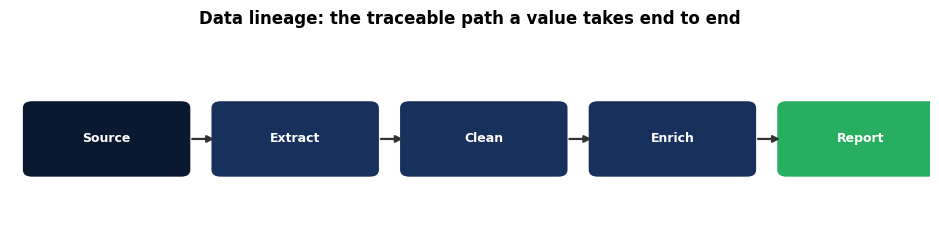

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 2.6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")

def box(x, y, w, h, text, facecolor, fontsize=9):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.06,rounding_size=0.1",
        facecolor=facecolor, edgecolor="none"
    ))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            color="white", fontsize=fontsize, fontweight="bold")

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y1), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#333333", lw=1.6))

labels = ["Source", "Extract", "Clean", "Enrich", "Report"]
colors = ["#0A1830", "#17305C", "#17305C", "#17305C", "#27AE60"]
x = 0.2
w = 1.7
for i, (label, color) in enumerate(zip(labels, colors)):
    box(x, 1.0, w, 1.0, label, color)
    if i > 0:
        arrow(x - 0.3, 1.5, x, 1.5)
    x += w + 0.35

ax.set_title("Data lineage: the traceable path a value takes end to end",
             fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()


In [7]:
def with_lineage(step_name):
    def decorator(fn):
        def wrapper(record):
            output = fn(record)
            entry = {"step": step_name, "before": record.get("value"), "after": output.get("value")}
            output["lineage"] = record.get("lineage", []) + [entry]
            return output
        return wrapper
    return decorator

@with_lineage("extract")
def extract_step(record):
    return {"value": record["value"]}

@with_lineage("clean")
def clean_step(record):
    return {"value": record["value"].strip().title()}

@with_lineage("enrich")
def enrich_step(record):
    return {"value": f"{record['value']} (verified)"}

raw = {"value": "  bob diaz "}
step1 = extract_step(raw)
step2 = clean_step(step1)
final = enrich_step(step2)

print(f"Final value: {final['value']!r}\n")
print("Lineage, traced back through every step that touched it:")
for entry in final["lineage"]:
    print(f"  [{entry['step']:<8}] {entry['before']!r} -> {entry['after']!r}")


Final value: 'Bob Diaz (verified)'

Lineage, traced back through every step that touched it:
  [extract ] '  bob diaz ' -> '  bob diaz '
  [clean   ] '  bob diaz ' -> 'Bob Diaz'
  [enrich  ] 'Bob Diaz' -> 'Bob Diaz (verified)'


## Section C — Data Catalog

The inventory that helps people find and understand what data exists. Below: a small searchable registry of datasets.


In [9]:
catalog = [
    {"name": "customers", "description": "One row per customer account.", "owner": "Data GOLD",
     "columns": ["id", "name", "email", "mrr", "state"], "tags": ["pii", "core"]},
    {"name": "orders", "description": "One row per completed order.", "owner": "Data GOLD",
     "columns": ["order_id", "customer_id", "order_date", "amount"], "tags": ["core", "revenue"]},
    {"name": "warehouse_sales", "description": "Aggregated sales by category, warehouse-modeled.", "owner": "Analytics",
     "columns": ["sale_id", "product", "category", "amount"], "tags": ["revenue", "reporting"]},
]

def search_catalog(query):
    query = query.lower()
    return [
        entry for entry in catalog
        if query in entry["name"].lower()
        or query in entry["description"].lower()
        or any(query in tag for tag in entry["tags"])
        or any(query in col.lower() for col in entry["columns"])
    ]

print("Searching the catalog for 'revenue':\n")
for entry in search_catalog("revenue"):
    print(f"  {entry['name']}: {entry['description']} (owner: {entry['owner']})")

print("\nSearching the catalog for 'pii':\n")
for entry in search_catalog("pii"):
    print(f"  {entry['name']}: {entry['description']} (owner: {entry['owner']})")


Searching the catalog for 'revenue':

  orders: One row per completed order. (owner: Data GOLD)
  warehouse_sales: Aggregated sales by category, warehouse-modeled. (owner: Analytics)

Searching the catalog for 'pii':

  customers: One row per customer account. (owner: Data GOLD)


## Section D — Fault Tolerance

The system keeps running even when parts of it fail. Below: a flaky service that fails twice, recovered by retry logic and, if that fails too, a fallback.


In [11]:
class FlakyService:
    def __init__(self, fail_times):
        self.attempts = 0
        self.fail_times = fail_times

    def call(self):
        self.attempts += 1
        if self.attempts <= self.fail_times:
            raise ConnectionError(f"attempt {self.attempts} failed")
        return {"status": "ok", "attempt": self.attempts}

def call_with_retry(service, max_retries=3, fallback=None):
    for attempt in range(1, max_retries + 1):
        try:
            return service.call()
        except ConnectionError as e:
            print(f"  attempt {attempt} failed: {e}")
    if fallback is not None:
        print("  all retries exhausted, falling back")
        return fallback()
    raise RuntimeError("service unavailable, no fallback configured")

service = FlakyService(fail_times=2)
print("Service fails twice, then recovers on the third attempt:\n")
result = call_with_retry(service, max_retries=3, fallback=lambda: {"status": "degraded"})
print(f"\nFinal result: {result}")


Service fails twice, then recovers on the third attempt:

  attempt 1 failed: attempt 1 failed
  attempt 2 failed: attempt 2 failed

Final result: {'status': 'ok', 'attempt': 3}


## Section E — Elasticity vs. Scalability

Related, not the same. Elasticity is resources adjusting automatically as demand shifts, up and down. Scalability is the capacity to keep working as load grows, by adding resources.


### 5. Elasticity — scaling to match demand as it changes


In [13]:
def workers_needed(load):
    return max(1, -(-load // 100))  # 1 worker per 100 units of load, ceiling division

load_over_time = [50, 220, 480, 150, 30]
print("Worker count adjusts automatically as load rises and falls:\n")
for t, load in enumerate(load_over_time):
    workers = workers_needed(load)
    print(f"  t={t}: load={load:>4} -> {workers} worker(s) provisioned")


Worker count adjusts automatically as load rises and falls:

  t=0: load=  50 -> 1 worker(s) provisioned
  t=1: load= 220 -> 3 worker(s) provisioned
  t=2: load= 480 -> 5 worker(s) provisioned
  t=3: load= 150 -> 2 worker(s) provisioned
  t=4: load=  30 -> 1 worker(s) provisioned


### 6. Scalability — capacity as resources are added


In [15]:
def time_to_process(total_work, num_workers):
    return (total_work / num_workers) * 0.001  # arbitrary time cost per unit of work

total_work = 10000
print(f"Fixed workload of {total_work:,} units, more resources added:\n")
for workers in [1, 2, 4, 8]:
    time_cost = time_to_process(total_work, workers)
    throughput = total_work / time_cost
    print(f"  {workers} worker(s): completes in {time_cost:.2f}s -> throughput {throughput:,.0f} units/sec")

print("\nThroughput scales with the resources added. That's the whole test.")


Fixed workload of 10,000 units, more resources added:

  1 worker(s): completes in 10.00s -> throughput 1,000 units/sec
  2 worker(s): completes in 5.00s -> throughput 2,000 units/sec
  4 worker(s): completes in 2.50s -> throughput 4,000 units/sec
  8 worker(s): completes in 1.25s -> throughput 8,000 units/sec

Throughput scales with the resources added. That's the whole test.


---
### Recap

| Term | The one-line test |
|---|---|
| **Data Quality** | Is the data accurate, consistent, and reliable enough to act on? |
| **Data Lineage** | Can you trace exactly where a value came from and what changed it? |
| **Data Catalog** | Can someone find and understand a dataset without asking a person first? |
| **Fault Tolerance** | Does the system keep running when a part of it fails? |
| **Elasticity** | Do resources adjust automatically as demand rises and falls? |
| **Scalability** | Does throughput keep pace as resources are added to a growing workload? |

**Data GOLD** — Turning data complexity into business GOLD.
